202235275 심찬기



Train data: (10000, 32, 32, 3)
Train label: (10000,)
Test data: (2000, 32, 32, 3)
Test label: (2000,)


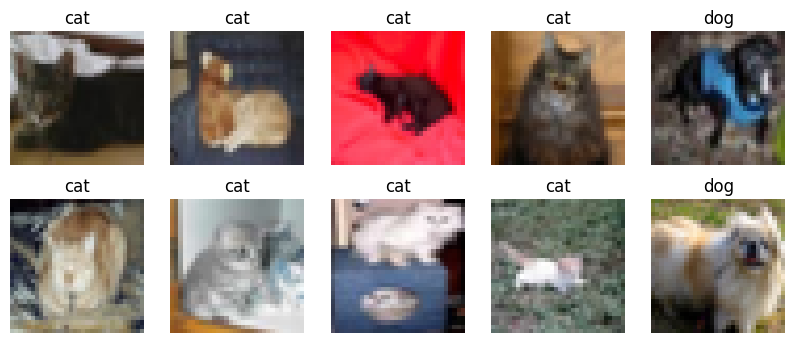

In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers, models, Sequential
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import *




# =========================

# 1. CIFAR-10 데이터 로드

# =========================



(x_train, y_train), (x_test, y_test) = cifar10.load_data()



# CIFAR-10 class index

# airplane: 0

# automobile: 1

# bird: 2

# cat: 3

# deer: 4

# dog: 5

# frog: 6

# horse: 7

# ship: 8

# truck: 9



CAT_LABEL = 3

DOG_LABEL = 5



# =========================

# 2. Cat / Dog 데이터만 선택

# =========================



train_mask = np.where((y_train[:, 0] == CAT_LABEL) | (y_train[:, 0] == DOG_LABEL))[0]

test_mask = np.where((y_test[:, 0] == CAT_LABEL) | (y_test[:, 0] == DOG_LABEL))[0]



x_train_cd = x_train[train_mask]

y_train_cd = y_train[train_mask]



x_test_cd = x_test[test_mask]

y_test_cd = y_test[test_mask]



# =========================

# 3. 라벨 변환

# cat -> 0

# dog -> 1

# =========================



y_train_cd = np.where(y_train_cd[:, 0] == CAT_LABEL, 0, 1)

y_test_cd = np.where(y_test_cd[:, 0] == CAT_LABEL, 0, 1)



# =========================

# 4. 정규화

# =========================



x_train_cd = x_train_cd.astype("float32") / 255.0

x_test_cd = x_test_cd.astype("float32") / 255.0



print("Train data:", x_train_cd.shape)

print("Train label:", y_train_cd.shape)

print("Test data:", x_test_cd.shape)

print("Test label:", y_test_cd.shape)



# =========================

# 5. 데이터 확인

# =========================



class_names = ["cat", "dog"]



plt.figure(figsize=(10, 4))

for i in range(10):

    plt.subplot(2, 5, i + 1)

    plt.imshow(x_train_cd[i])

    plt.title(class_names[y_train_cd[i]])

    plt.axis("off")

plt.show()

In [4]:
model = Sequential()
model.add(Conv2D(64, activation='relu',kernel_size=(3,3)))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Conv2D(32, activation='relu',kernel_size=(3,3)))
model.add(Flatten(input_shape=(32,32,3)))
model.add(Dense(80,activation='relu'))
model.add(Dense(10,activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [5]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])
history=model.fit(x_train_cd,y_train_cd,epochs=10,verbose=1,validation_split=0.3)

Epoch 1/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 9s 38ms/step - accuracy: 0.5651 - loss: 0.6999 - val_accuracy: 0.5373 - val_loss: 0.7246
Epoch 2/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 8s 35ms/step - accuracy: 0.6407 - loss: 0.6321 - val_accuracy: 0.6673 - val_loss: 0.6105
Epoch 3/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 10s 32ms/step - accuracy: 0.6771 - loss: 0.5919 - val_accuracy: 0.6830 - val_loss: 0.5934
Epoch 4/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 9s 39ms/step - accuracy: 0.7116 - loss: 0.5572 - val_accuracy: 0.6617 - val_loss: 0.6209
Epoch 5/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 10s 36ms/step - accuracy: 0.7196 - loss: 0.5394 - val_accuracy: 0.7023 - val_loss: 0.5711
Epoch 6/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 10s 36ms/step - accuracy: 0.7471 - loss: 0.5077 - val_accuracy: 0.6793 - val_loss: 0.6143
Epoch 7/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 7s 34ms/step - accuracy: 0.7649 - loss: 0.4879 - val_accuracy: 0.7053 - val_loss: 0.5788
Epoch 8/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 8s 34ms/step - accuracy: 0.7791 - loss: 0.4605 - val_a

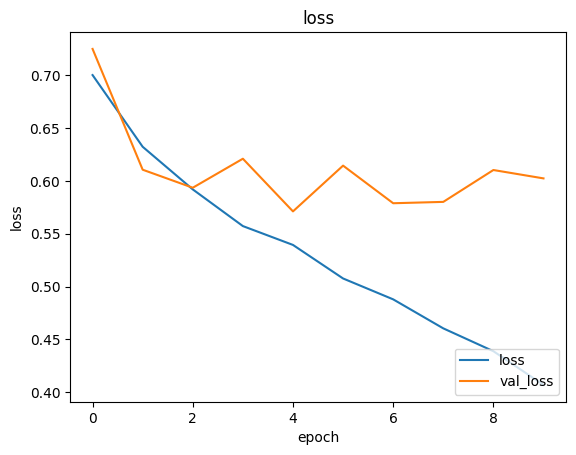

In [6]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['loss','val_loss'],loc = 'lower right')
plt.show()

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step
정답= [3]
예측값= [6.0863119e-01 3.9136338e-01 4.4723319e-07 3.7207323e-07 1.9648378e-07
 3.9876917e-07 7.8671206e-07 1.7657691e-06 8.5633945e-07 6.1214587e-07]


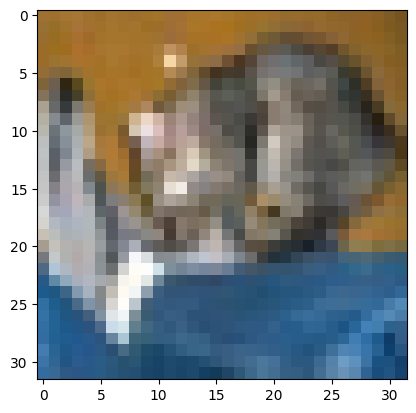

In [8]:
plt.figure()
plt.imshow(x_test_cd[0])
y_pred = model.predict(x_test_cd)
print("정답=",y_test[0])
print("예측값=",y_pred[0])